# WINMOL Analyzer — running PyTorch models via **ONNX**, and comparing three backends

This notebook shows how to run a **PyTorch-trained** segmentation model through the analyzer
pipeline with **no architecture code**, and finishes with a **side-by-side comparison** of
three models that all satisfy the same `[N,3,512,512] → sigmoid [N,1,512,512]` contract:

| # | Model | Format | Trained in | Runtime |
|---|-------|--------|-----------|---------|
| 1 | U-Net | Keras **HDF5** | R (original Zenodo model) | TensorFlow + Metal |
| 2 | U-Net | **ONNX** | Python (`WINMOL_segmentor_pt`) | onnxruntime + CoreML |
| 3 | DeepLabV3+ | **ONNX** | Python (`WINMOL_segmentor_pt`) | onnxruntime + CoreML |

`IO.load_model_from_path()` dispatches on extension: `.onnx` → `winmol_unet.runtime.OnnxSegmenter`
(duck-types the Keras model's `predict_on_batch(NHWC)`), `.hdf5`/`.keras` → `keras.models.load_model`.
Because all three expose the same interface, every downstream stage (skeletonize → vectorize →
quantify) is identical.

> Requires `winmol_unet` installed (`pip install -e /path/to/WINMOL_segmentor_pt`, pulls in
> onnxruntime). See `docs/winmol_unet-pytorch-bridge.md`.

## 0. Setup

We enable the **legacy-Keras shim** (`TF_USE_LEGACY_KERAS=1`) because the original **R-trained model is a Keras 2 HDF5** and won't load under the Keras 3 bundled with TF ≥ 2.16. The ONNX models ignore this setting entirely (they never touch Keras).

In [1]:
import os
import sys

# Required for the Keras-2 HDF5 (R-trained) model in the comparison below.
# Harmless for the ONNX models. Must be set before TensorFlow is imported.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

ROOT_DIR = os.path.abspath(".")
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

import WINMOL_Analyzer as Analyzer
from WINMOL_Analyzer import Config, Timer

import onnxruntime as ort
print("onnxruntime:", ort.__version__, "| providers:", ort.get_available_providers())

onnxruntime: 1.27.0 | providers: ['CoreMLExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']


## 1. Parameters — set input models, ortho, and **OUTPUT directory**

`WINDOW_SIZE=None` runs the whole mosaic; a pixel value crops a fast window.

In [2]:
# --- The three models to compare (edit paths as needed) ---
PT_REPO = "/Users/christian/work/work/WINMOL_segmentor_pt"
MODELS = {
    "U-Net HDF5 (R)":  os.path.join(
        ROOT_DIR, "model", "model_UNet_GenDS_512_2023-02-27_211141.hdf5"),
    "U-Net ONNX (py)": os.path.join(PT_REPO, "output", "aug-test", "model.onnx"),
    "DeepLab ONNX":    os.path.join(PT_REPO, "output", "deeplab", "model.onnx"),
}
# The single-model walkthrough (sections 3-8) uses this one:
MODEL_ONNX_PATH = MODELS["DeepLab ONNX"]

ORTHO_PATH = os.path.join(
    ROOT_DIR, "input",
    "repr_20250327_171_4_Kraking_Windwurf_SELEKTION.tif")

OUTPUT_DIR = os.path.join(ROOT_DIR, "output", "deeplab_onnx")   # EDIT ME
os.makedirs(OUTPUT_DIR, exist_ok=True)
FILE_NAME = "deeplab_onnx"

WINDOW_SIZE = 2048     # pixels; None -> full orthomosaic
COL_OFF = None
ROW_OFF = None


def extent_from_profile(p):
    t = p["transform"]
    left, top = t.c, t.f
    return (left, left + t.a * p["width"], top + t.e * p["height"], top)


def stretch_rgb(rgb, lo=2, hi=98):
    """Per-band percentile contrast stretch, DISPLAY ONLY."""
    out = np.empty_like(rgb, dtype="float32")
    for i in range(rgb.shape[2]):
        b = rgb[..., i]
        p_lo, p_hi = np.percentile(b, [lo, hi])
        out[..., i] = np.clip((b - p_lo) / max(p_hi - p_lo, 1e-6), 0, 1)
    return out


for k, v in MODELS.items():
    print(f"{k:16s} {'OK' if os.path.exists(v) else 'MISSING'}  {v}")
print("Output:", OUTPUT_DIR)

U-Net HDF5 (R)   OK  /Users/christian/hnee/WINMOL_Analyzer/standalone/model/model_UNet_GenDS_512_2023-02-27_211141.hdf5
U-Net ONNX (py)  OK  /Users/christian/work/work/WINMOL_segmentor_pt/output/aug-test/model.onnx
DeepLab ONNX     OK  /Users/christian/work/work/WINMOL_segmentor_pt/output/deeplab/model.onnx
Output: /Users/christian/hnee/WINMOL_Analyzer/standalone/output/deeplab_onnx


## 2. Configuration

In [3]:
config = Config()
config.display()


Configurations:
compress_output                True
cpu_workers                    None
diameter_method                contour
diameter_vector_half_length_m  1.0
edt_clip_max_m                 None
gpu_memory_fraction            0.9
gpu_workers                    None
img_bit                        8
img_height                     512
img_width                      512
keep_temp_tiles                False
max_cpu_workers                32
max_distance                   8
max_gpu_workers                8
max_tree_height                32
max_vector_tile_workers        4
measuring_point_spacing_m      0.5
min_length                     2.0
multi_gpu_cpu_workers          48
n_channels                     3
num_classes                    1
overlap_pred                   8
prediction_backend             auto
prediction_batch_autotune      True
prediction_batch_autotune_min_improve 0.005
prediction_batch_autotune_patience 4
prediction_batch_autotune_quiet True
prediction_batch_autotune_repe

## 3. Load the DeepLabV3+ model from ONNX — no architecture code

`load_model_from_path` returns an `OnnxSegmenter` (CoreML on Apple Silicon).

In [4]:
model = Analyzer.IO.load_model_from_path(MODEL_ONNX_PATH)
print("Loaded   :", type(model).__module__ + "." + type(model).__name__)
print("Providers:", model.session.get_providers())
model.summary()
# For exact fp32 parity instead of CoreML fp16, set
# os.environ["WINMOL_ONNX_FORCE_CPU"]="1" before this cell and re-run.

Loading ONNX model via OnnxSegmenter: /Users/christian/work/work/WINMOL_segmentor_pt/output/deeplab/model.onnx


Loaded   :

 winmol_unet.runtime.OnnxSegmenter
Providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
OnnxSegmenter(providers=['CoreMLExecutionProvider', 'CPUExecutionProvider']) input=[N,512,512,3] -> output=[N,512,512,1] (NHWC)


2026-07-10 11:21:06.714 python3.11[41616:5236302] 2026-07-10 11:21:06.714785 [W:onnxruntime:, coreml_execution_provider.cc:137 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 4 number of nodes in the graph: 126 number of nodes supported by CoreML: 119


## 4. Load & (optionally) crop the orthomosaic

Area: (2048, 2048, 3) | CRS EPSG:25833


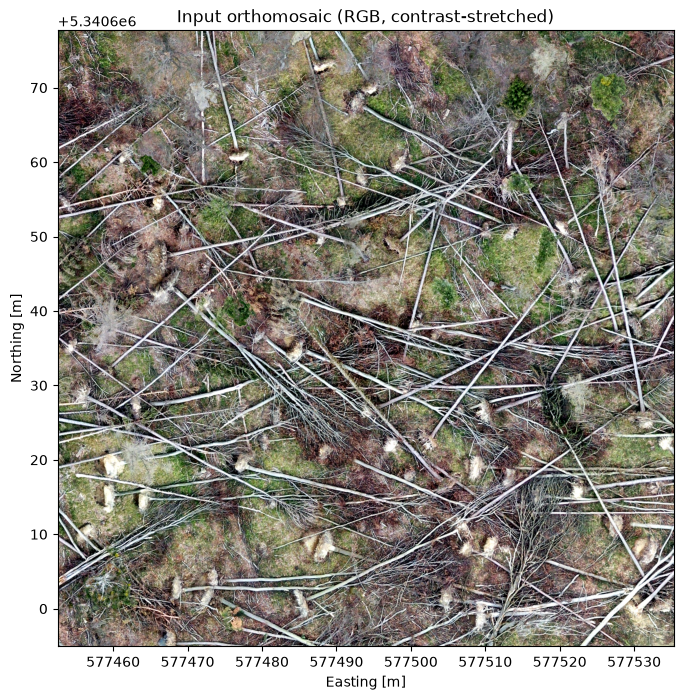

In [5]:
with rasterio.open(ORTHO_PATH) as src:
    full = WINDOW_SIZE is None
    w = src.width if full else min(WINDOW_SIZE, src.width)
    h = src.height if full else min(WINDOW_SIZE, src.height)
    col = 0 if full else ((src.width - w) // 2 if COL_OFF is None else COL_OFF)
    row = 0 if full else ((src.height - h) // 2 if ROW_OFF is None else ROW_OFF)
    window = Window(col, row, w, h)
    bands = min(3, src.count)
    data = src.read(list(range(1, bands + 1)), window=window)
    profile0 = src.profile.copy()
    profile0.update(width=w, height=h, count=bands,
                    transform=src.window_transform(window), driver="GTiff")
    profile0.pop("nodata", None)

crop_path = os.path.join(OUTPUT_DIR, FILE_NAME + "_input.tif")
with rasterio.open(crop_path, "w", **profile0) as dst:
    dst.write(data)

img, profile = Analyzer.IO.load_orthomosaic(crop_path, config)
EXTENT = extent_from_profile(profile)
img_disp = stretch_rgb(img)
print("Area:", img.shape, "| CRS", profile.get("crs"))

plt.figure(figsize=(8, 8))
plt.imshow(img_disp, extent=EXTENT)
plt.title("Input orthomosaic (RGB, contrast-stretched)")
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]"); plt.show()

## 5. Predict the semantic stem map

#######################################################
Prediction of the semantic stem map
Resampling tiles while analyzing


36  tiles analyzed
Elapsed time: 8.4662 seconds
#######################################################

Elapsed time: 8.4691 seconds


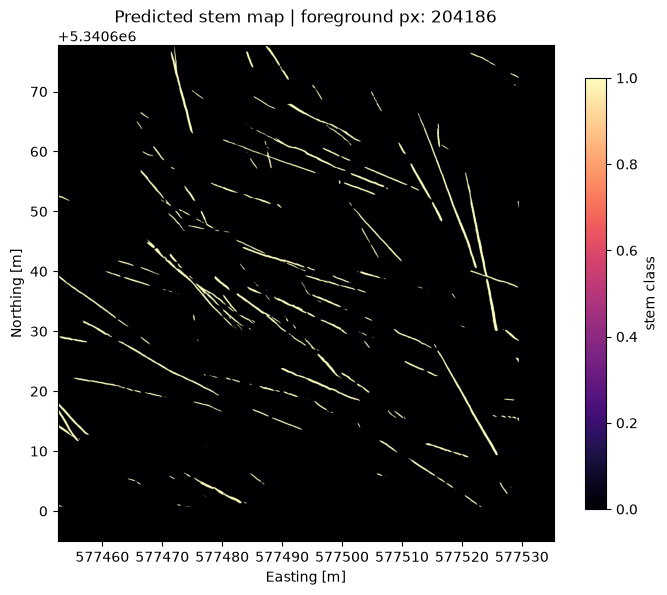

In [6]:
tt = Timer(); tt.start()
pred, profile = Analyzer.Pred.predict_with_resampling_per_tile(
    img, profile, model, config)
tt.stop()

plt.figure(figsize=(8, 8))
plt.imshow(pred, cmap="magma", extent=EXTENT)
plt.title("Predicted stem map | foreground px: %d" % int((pred >= 1).sum()))
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]")
plt.colorbar(shrink=0.7, label="stem class"); plt.show()

## 6. Vectorize → connect → quantify

In [7]:
segments = Analyzer.Skel.find_segments(pred, config, profile)
segments = Analyzer.Vec.restore_geoinformation(segments, config, profile)
stems = Analyzer.Vec.build_stem_parts(segments)
stems = Analyzer.Vec.connect_stems(stems, config)
Analyzer.Vec.rebuild_endnodes_from_stems(stems)
stems = Analyzer.Quant.quantify_stems(stems, pred, profile)

gdf = Analyzer.IO.stems_to_gdf(stems, profile)
print("%d stems | total length %.1f m | total volume %.2f m3"
      % (len(stems), gdf["length"].sum(), gdf["volume"].sum()))
gdf[["length", "volume"]].describe()

#######################################################
Skeletonize Image


Elapsed time: 1.4290 seconds
#######################################################

#######################################################
Splitting the skeleton into segments and detecting endnodes


Dense nodes removed:  0
Elapsed time: 6.4633 seconds
Find skeletion nodes


Remove branch points
Find skeletion nodes


Branch points removed:  39
Detected end nodes:  674
Elapsed time: 5.0255 seconds
#######################################################

#######################################################
Find connected segments in the skeleton
Initial length of skeleton:  21946
Number of end nodes 674
Minimum length in pixel:  4


...

Cycle  2



220 stem segments analyzed
61 stem segments appended to other stems
18 duplicates are removed
63 stem fragments with a length less than  2.0 m are filtered out
final number of stems 78
Elapsed time: 7.6583 seconds
#######################################################

#######################################################
Rebuild endnodes from stems
Elapsed time: 0.0024 seconds
#######################################################

#######################################################
Quantifying stems


1215  measurements of diameters where conducted


Volume of  78  stems calculated
Elapsed time: 11.1091 seconds
#######################################################

78 stems | total length 726.4 m | total volume 40.59 m3


,length,volume
count,78.000000,78.000000
mean,9.312866,0.520398
std,7.236390,0.599136
min,2.068231,0.021624
25%,3.417504,0.133915
50%,6.548270,0.323019
75%,12.740736,0.623994
max,29.572185,3.600350


## 7. Stems overlaid on the orthomosaic

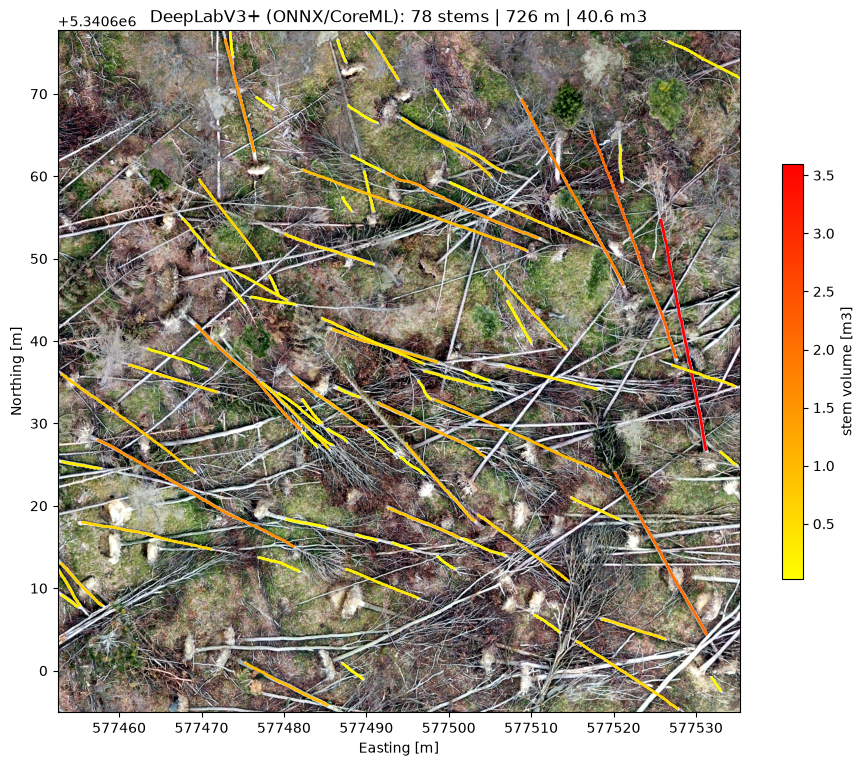

In [8]:
gdf_nodes = Analyzer.IO.nodes_to_gdf(stems, profile)
fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(img_disp, extent=EXTENT)
gdf.plot(ax=ax, column="volume", cmap="autumn_r", linewidth=2.0, legend=True,
         legend_kwds={"label": "stem volume [m3]", "shrink": 0.6})
gdf_nodes.plot(ax=ax, color="white", markersize=2, alpha=0.5)
ax.set_title("DeepLabV3+ (ONNX/CoreML): %d stems | %.0f m | %.1f m3"
             % (len(stems), gdf["length"].sum(), gdf["volume"].sum()))
ax.set_xlabel("Easting [m]"); ax.set_ylabel("Northing [m]")
fig.savefig(os.path.join(OUTPUT_DIR, FILE_NAME + "_overlay.png"),
            dpi=110, bbox_inches="tight")
plt.show()

## 8. Export outputs to `OUTPUT_DIR`

In [9]:
Analyzer.IO.export_stem_map(pred, profile, OUTPUT_DIR, FILE_NAME)
gpkg_path = Analyzer.IO.write_all_layers_to_gpkg(
    stems, profile, os.path.join(OUTPUT_DIR, FILE_NAME))
print("Stem map  ->", os.path.join(OUTPUT_DIR, FILE_NAME + ".tiff"))
print("GeoPackage->", gpkg_path)

Geopackage written to temporary file: /Users/christian/hnee/WINMOL_Analyzer/standalone/output/deeplab_onnx/winmol_gpkg_m5wd9jk3/deeplab_onnx.gpkg
Stem map  -> /Users/christian/hnee/WINMOL_Analyzer/standalone/output/deeplab_onnx/deeplab_onnx.tiff
GeoPackage-> /Users/christian/hnee/WINMOL_Analyzer/standalone/output/deeplab_onnx/deeplab_onnx.gpkg


## 9. Side-by-side comparison: R-UNet HDF5 vs Python-UNet ONNX vs DeepLab ONNX

We run all three models on the **same** cropped window and compare their predicted stem maps,
the reconstructed stems, and summary metrics. The only thing that changes between them is the
model file path handed to `load_model_from_path` — the pipeline code is identical.

In [10]:
import time as _t


def run_model(name, path):
    """Load a model (HDF5 or ONNX), predict + vectorize + quantify on `img`."""
    m = Analyzer.IO.load_model_from_path(path)
    sess = getattr(m, "session", None)
    backend = (sess.get_providers()[0] if sess is not None
               else "TensorFlow/Metal")
    fmt = "ONNX" if str(path).lower().endswith(".onnx") else "Keras HDF5"

    t0 = _t.time()
    p, prof = Analyzer.Pred.predict_with_resampling_per_tile(
        img, profile, m, config)
    pred_s = _t.time() - t0

    segs = Analyzer.Skel.find_segments(p, config, prof)
    segs = Analyzer.Vec.restore_geoinformation(segs, config, prof)
    st = Analyzer.Vec.build_stem_parts(segs)
    st = Analyzer.Vec.connect_stems(st, config)
    Analyzer.Vec.rebuild_endnodes_from_stems(st)
    st = Analyzer.Quant.quantify_stems(st, p, prof)
    g = Analyzer.IO.stems_to_gdf(st, prof)

    return {
        "name": name, "format": fmt, "backend": backend,
        "pred_s": pred_s, "stem_px_pct": 100.0 * float((p >= 1).mean()),
        "n_stems": len(st), "length_m": float(g["length"].sum()),
        "volume_m3": float(g["volume"].sum()),
        "pred": p, "gdf": g,
    }


results = [run_model(n, p) for n, p in MODELS.items()]
print("done:", [r["name"] for r in results])

Trying to load model using open_model()


#######################################################
Prediction of the semantic stem map
Resampling tiles while analyzing


25  tiles analyzed
Elapsed time: 58.2293 seconds
#######################################################

#######################################################
Skeletonize Image


Elapsed time: 2.7017 seconds
#######################################################

#######################################################
Splitting the skeleton into segments and detecting endnodes


Dense nodes removed:  41
Elapsed time: 4.2191 seconds
Find skeletion nodes


...

Detected skeleton segments:  132
Elapsed time: 1.8929 seconds
#######################################################

#######################################################
#Refining and sorting out skeleton segments
Initial length of skeleton:  10059
Number of initial skeleton segments 132


Number of split segments: 46
Number of removed segments: 74
Number of refined segments: 104
Elapsed time: 2.6208 seconds
#######################################################

#######################################################
Restoring geoinformation
Elapsed time: 0.0043 seconds
#######################################################

#######################################################
Build stem segments
104 stems segments build
Elapsed time: 0.0044 seconds
#######################################################

#######################################################
Gathering stem segments
Cycle  1


Cycle  2

104 stem segments analyzed
30 stem segments appended to other stems
4 duplicates are removed
30 stem fragments with a length less than  2.0 m are filtered out
final number of stems 40
Elapsed time: 0.5060 seconds
#######################################################

#######################################################
Rebuild endnodes from stems
Elapsed time: 0.0010 seconds
#######################################################

#######################################################
Quantifying stems


567  measurements of diameters where conducted


Volume of  40  stems calculated
Elapsed time: 10.8762 seconds
#######################################################

done: ['U-Net HDF5 (R)', 'U-Net ONNX (py)', 'DeepLab ONNX']


### 9a. Summary table

In [11]:
summary = pd.DataFrame([{
    "model": r["name"], "format": r["format"], "backend": r["backend"],
    "pred_time_s": round(r["pred_s"], 2),
    "stem_px_%": round(r["stem_px_pct"], 3),
    "n_stems": r["n_stems"],
    "length_m": round(r["length_m"], 1),
    "volume_m3": round(r["volume_m3"], 2),
} for r in results]).set_index("model")
summary

,format,backend,pred_time_s,stem_px_%,n_stems,length_m,volume_m3
model,,,,,,,
U-Net HDF5 (R),Keras HDF5,TensorFlow/Metal,58.24,7.125,140,1180.3,93.53
U-Net ONNX (py),ONNX,CoreMLExecutionProvider,26.49,0.506,13,102.2,4.31
DeepLab ONNX,ONNX,CoreMLExecutionProvider,3.38,1.206,40,340.1,12.00


### 9b. Predicted stem maps side by side

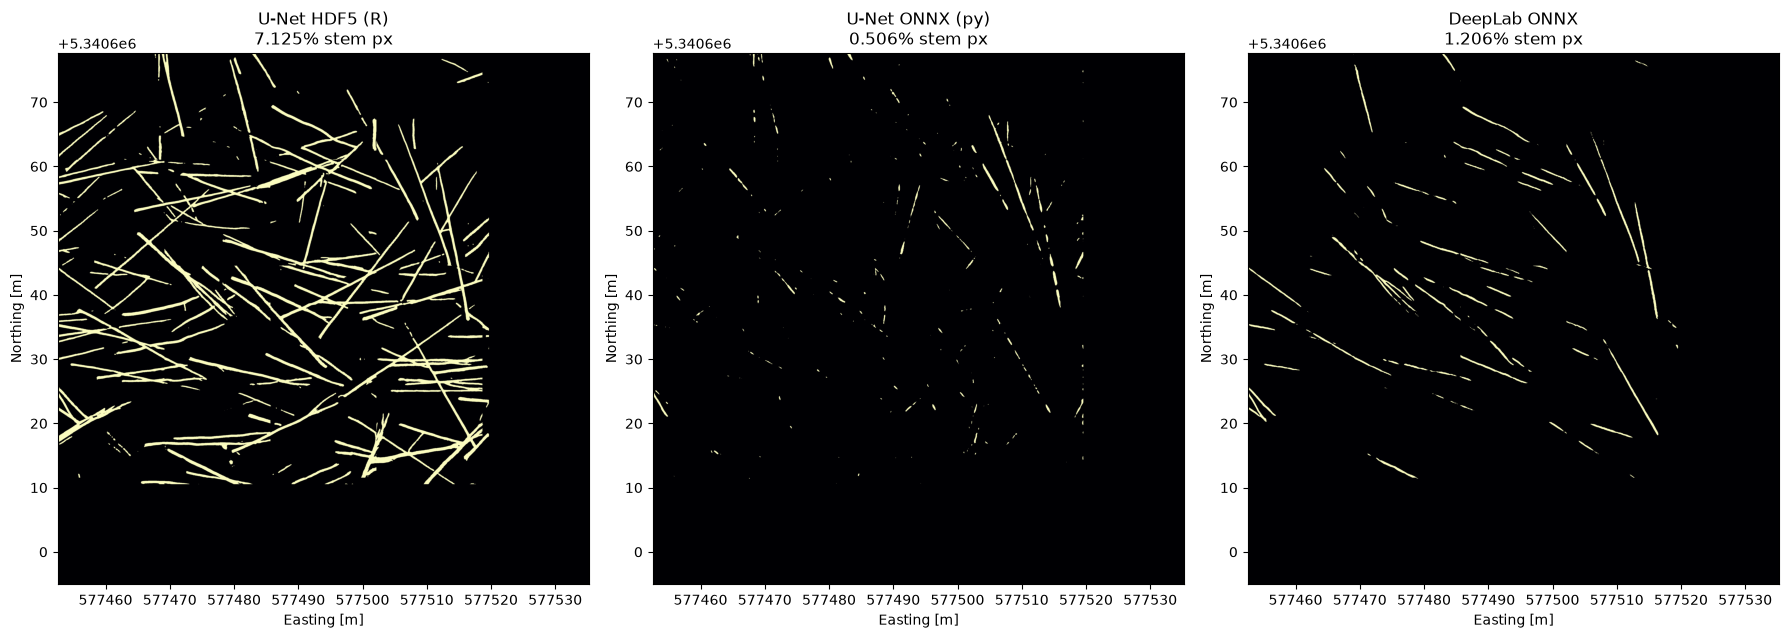

In [12]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
for ax, r in zip(np.atleast_1d(axes), results):
    ax.imshow(r["pred"], cmap="magma", extent=EXTENT)
    ax.set_title("%s\n%.3f%% stem px" % (r["name"], r["stem_px_pct"]))
    ax.set_xlabel("Easting [m]"); ax.set_ylabel("Northing [m]")
plt.tight_layout(); plt.show()

### 9c. Reconstructed stems overlaid on the ortho, side by side

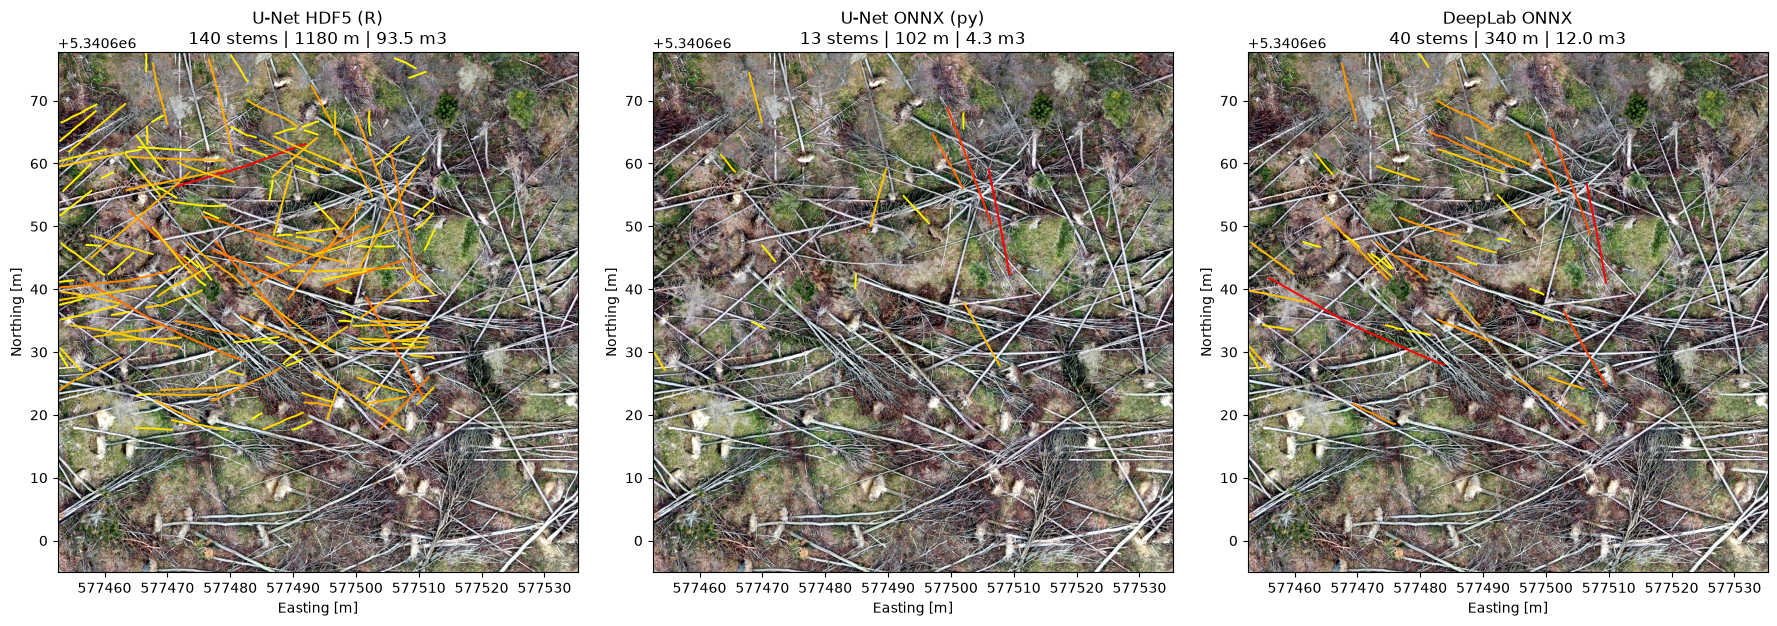

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
for ax, r in zip(np.atleast_1d(axes), results):
    ax.imshow(img_disp, extent=EXTENT)
    if len(r["gdf"]):
        r["gdf"].plot(ax=ax, column="volume", cmap="autumn_r", linewidth=1.4)
    ax.set_title("%s\n%d stems | %.0f m | %.1f m3"
                 % (r["name"], r["n_stems"], r["length_m"], r["volume_m3"]))
    ax.set_xlabel("Easting [m]"); ax.set_ylabel("Northing [m]")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "model_comparison_overlay.png"),
            dpi=110, bbox_inches="tight")
plt.show()

### Notes on the comparison

- **Same pipeline, three backends.** Only the model path differs; `load_model_from_path`
  handles HDF5 vs ONNX, and CoreML vs TensorFlow/Metal is chosen automatically.
- **The R U-Net HDF5 is the production-trained reference** and typically detects the most
  stems. The **Python U-Net ONNX** here is an early `aug-test` checkpoint (under-trained → few
  detections); it demonstrates the *format* works, not final accuracy. The **DeepLabV3+ ONNX**
  is a trained model and detects a realistic stem set.
- **Fair-accuracy caveat:** these are different training runs, so differences reflect model
  weights, not the runtime. For a pure runtime/parity check, compare the *same* ONNX under
  CoreML vs `WINMOL_ONNX_FORCE_CPU=1`.
- To compare on the **full mosaic**, set `WINDOW_SIZE=None` (slower). For production use the
  streamed runner: `python winmol_run.py <model.onnx|.hdf5> input.tif stem_map.tif out Trees`.